# POLYHAQ — Feature-space Expansion Using Quantum Walks

This notebook provides a leakage-safe experimental scaffold for the Breast Cancer Wisconsin dataset. It deliberately does **not** implement the external 1D or 2D Quantum Walk physics.


# 1. Experiment Configuration


In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
PRIMARY_METRIC = "f1_macro"
ALPHA = 0.05
EPSILON = 1e-8

T_VALUES_1D = list(range(1, 11))
T_VALUES_2D = list(range(1, 11))
T_SCREEN_VALUES_2D = [T_VALUES_2D[0], T_VALUES_2D[len(T_VALUES_2D) // 2], T_VALUES_2D[-1]]

N_SPLITS = 5
N_MAPPING_SCREEN_2D = 200
TOP_K_MAPPING_2D = 10
EXHAUSTIVE_2D_FULL_SEARCH = False
RUN_QW_EXPERIMENTS = False  # Enable only after external QW runners are connected.

# Provisional reference convention: the runner still receives all ten encoded
# parameters, but when use_mu_chi=False it must ignore encoded mu/chi and use
# these fixed reference values. Physics-team confirmation is required.
MU_CHI_REFERENCE = {"mu": 0.0, "chi": 0.0}


The ML classifier is intentionally simple and fixed. The objective is to evaluate feature expansion—not classifier complexity. All feature, mapping, and $T$ choices must use cross-validation inside the training partition; the Test set is reserved for one final, unbiased evaluation.


# 2. Imports


In [ ]:
import itertools
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler

np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")


# 3. Dataset Loading


In [3]:
dataset = load_breast_cancer()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")
target_names = dict(enumerate(dataset.target_names))

print(f"Samples: {X.shape[0]} | Features: {X.shape[1]}")
print("Targets:", target_names)


Samples: 569 | Features: 30
Targets: {0: np.str_('malignant'), 1: np.str_('benign')}


# 4. Dataset Audit


In [4]:
audit = pd.DataFrame(
    {
        "dtype": X.dtypes.astype(str),
        "missing": X.isna().sum(),
        "unique": X.nunique(),
        "mean": X.mean(),
        "std": X.std(),
    }
)

class_balance = y.value_counts().sort_index().rename(index=target_names).to_frame("count")
class_balance["proportion"] = class_balance["count"] / len(y)

display(class_balance)
display(audit.head())
assert not X.isna().any().any(), "Unexpected missing feature values."
assert not y.isna().any(), "Unexpected missing targets."


,count,proportion
target,,
malignant,212,0.372583
benign,357,0.627417


,dtype,missing,unique,mean,std
mean radius,float64,0,456,14.127292,3.524049
mean texture,float64,0,479,19.289649,4.301036
mean perimeter,float64,0,522,91.969033,24.298981
mean area,float64,0,539,654.889104,351.914129
mean smoothness,float64,0,474,0.096360,0.014064


# 5. Train/Test Split

Exactly one stratified 80/20 split is created. There is no separate holdout validation split: validation is performed exclusively with stratified folds inside `X_train` and `y_train`.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)


def make_stratified_cv():
    """Return a fresh, reproducible five-fold training-only CV splitter."""
    return StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )


cv = make_stratified_cv()

print("Training partition:", X_train.shape)
print("Reserved test partition:", X_test.shape)
print("Cross-validation: 5 stratified folds, shuffled with RANDOM_STATE")


Training partition: (455, 30)
Reserved test partition: (114, 30)
Cross-validation: 5 stratified folds, shuffled with RANDOM_STATE


# 6. Feature Selection

The 4-feature and 10-feature views match the 1D and 2D parameter counts. Mutual-information selectors are fitted on training data only. Any performance-based choice involving features must be made inside training folds.


In [6]:
def select_features_mi(X_train, y_train, X_eval, k):
    """Fit SelectKBest on training data and transform train/evaluation matrices."""
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train must be a DataFrame so feature names are preserved.")
    if not 1 <= k <= X_train.shape[1]:
        raise ValueError("k must be between 1 and the number of input features.")

    score_func = lambda values, labels: mutual_info_classif(
        values,
        labels,
        random_state=RANDOM_STATE,
    )
    selector = SelectKBest(score_func=score_func, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_eval_selected = selector.transform(X_eval)
    selected_indices = selector.get_support(indices=True)
    selected_feature_names = X_train.columns[selected_indices].tolist()
    mi_scores = selector.scores_[selected_indices]

    return {
        "selector": selector,
        "selected_indices": selected_indices,
        "selected_feature_names": selected_feature_names,
        "mi_scores": mi_scores,
        "X_train": X_train_selected,
        "X_eval": X_eval_selected,
        # Compatibility aliases used by the later experiment scaffold.
        "indices": selected_indices,
        "names": selected_feature_names,
        "scores": mi_scores,
    }


def ranked_mi_table(selection):
    table = pd.DataFrame(
        {
            "feature": selection["selected_feature_names"],
            "mutual_information_score": selection["mi_scores"],
        }
    ).sort_values("mutual_information_score", ascending=False, ignore_index=True)
    table.insert(0, "rank", np.arange(1, len(table) + 1))
    return table


# The evaluation matrix is training data here; the reserved test set is untouched.
features_1d = select_features_mi(X_train, y_train, X_train, k=4)
features_2d = select_features_mi(X_train, y_train, X_train, k=10)

features_1d_table = ranked_mi_table(features_1d)
features_2d_table = ranked_mi_table(features_2d)

print("1D selection (k=4)")
display(features_1d_table)
print("2D selection (k=10)")
display(features_2d_table)


1D selection (k=4)


,rank,feature,mutual_information_score
0,1,worst perimeter,0.471238
1,2,worst area,0.461952
2,3,worst radius,0.458392
3,4,mean concave points,0.443749


2D selection (k=10)


,rank,feature,mutual_information_score
0,1,worst perimeter,0.471238
1,2,worst area,0.461952
2,3,worst radius,0.458392
3,4,mean concave points,0.443749
4,5,worst concave points,0.442864
5,6,mean perimeter,0.411013
6,7,mean radius,0.364736
7,8,mean area,0.357780
8,9,mean concavity,0.353144
9,10,area error,0.337466


# 7. Classical Baselines

Both baselines use the exact same fixed `StandardScaler` + `LogisticRegression` architecture. The polynomial baseline changes only the feature space. Reported baseline-summary values are means from five training-only stratified folds; the Test set remains reserved for Section 17.


In [7]:
METRIC_COLUMNS = [
    "accuracy",
    "f1_macro",
    "f1_malignant",
    "precision_malignant",
    "recall_malignant",
]


def evaluate_classifier(X_train, X_eval, y_train, y_eval):
    """Fit the fixed classifier and evaluate it on one supplied evaluation set."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)

    model = LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_eval_scaled)

    return {
        "accuracy": accuracy_score(y_eval, predictions),
        "f1_macro": f1_score(y_eval, predictions, average="macro"),
        "f1_malignant": f1_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "precision_malignant": precision_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "recall_malignant": recall_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "predictions": predictions,
        "scaler": scaler,
        "model": model,
    }


def _take_rows(values, indices):
    return values.iloc[indices] if hasattr(values, "iloc") else np.asarray(values)[indices]


def evaluate_feature_space_cv(X_values, y_values, transformer=None):
    """Generate fold-local transformations and out-of-fold baseline metrics."""
    fold_records = []
    out_of_fold_predictions = np.empty(len(y_values), dtype=int)

    for fold, (fit_indices, eval_indices) in enumerate(
        make_stratified_cv().split(X_values, y_values), start=1
    ):
        X_fit = _take_rows(X_values, fit_indices)
        X_eval = _take_rows(X_values, eval_indices)
        y_fit = _take_rows(y_values, fit_indices)
        y_eval = _take_rows(y_values, eval_indices)

        if transformer is not None:
            fold_transformer = clone(transformer)
            X_fit = fold_transformer.fit_transform(X_fit)
            X_eval = fold_transformer.transform(X_eval)

        result = evaluate_classifier(X_fit, X_eval, y_fit, y_eval)
        fold_records.append({"fold": fold, **{key: result[key] for key in METRIC_COLUMNS}})
        out_of_fold_predictions[eval_indices] = result["predictions"]

    return {
        "fold_scores": pd.DataFrame(fold_records),
        "predictions": out_of_fold_predictions,
    }


# No classifier hyperparameters are tuned for either baseline.
polynomial_transformer = PolynomialFeatures(degree=2, include_bias=False)
original_cv_result = evaluate_feature_space_cv(X_train, y_train)
polynomial_cv_result = evaluate_feature_space_cv(
    X_train,
    y_train,
    transformer=polynomial_transformer,
)

original_cv_scores = original_cv_result["fold_scores"]
polynomial_cv_scores = polynomial_cv_result["fold_scores"]

# Fit a separate polynomial transformer on all training data for dimensions and later final use.
X_train_polynomial = polynomial_transformer.fit_transform(X_train)

baseline_summary = pd.DataFrame(
    [
        {
            "feature_space": "Original",
            "input_dimension": X_train.shape[1],
            **original_cv_scores[METRIC_COLUMNS].mean().to_dict(),
        },
        {
            "feature_space": "Polynomial degree 2",
            "input_dimension": X_train_polynomial.shape[1],
            **polynomial_cv_scores[METRIC_COLUMNS].mean().to_dict(),
        },
    ]
)

print("Training-only 5-fold CV baseline summary")
display(baseline_summary)

dimensions = pd.DataFrame(
    {
        "feature_space": [
            "Original features",
            "Polynomial features",
            "1D selected features",
            "2D selected features",
        ],
        "dimension": [
            X_train.shape[1],
            X_train_polynomial.shape[1],
            features_1d["X_train"].shape[1],
            features_2d["X_train"].shape[1],
        ],
    }
)
print("Feature-space dimensions")
display(dimensions)


Training-only 5-fold CV baseline summary


,feature_space,input_dimension,accuracy,f1_macro,f1_malignant,precision_malignant,recall_malignant
0,Original,30,0.978022,0.976426,0.970308,0.976975,0.964706
1,Polynomial degree 2,495,0.964835,0.962275,0.952473,0.959446,0.947059


Feature-space dimensions


,feature_space,dimension
0,Original features,30
1,Polynomial features,495
2,1D selected features,4
3,2D selected features,10


# 8. Quantum Parameter Encoding

This section only scales selected classical inputs and maps them into declared parameter ranges. It does not simulate a Quantum Walk.

> **Implementation note:** These ranges are implementation assumptions and must be confirmed with the physics team.


In [8]:
PARAMS_1D = ["theta1", "phi1", "alpha1", "beta1"]
PARAM_RANGES_1D = {
    "theta1": (0, np.pi),
    "phi1": (0, 2 * np.pi),
    "alpha1": (0, np.pi),
    "beta1": (0, 2 * np.pi),
}

PARAMS_2D = [
    "theta1", "phi1", "alpha1", "beta1",
    "theta2", "phi2", "alpha2", "beta2", "mu", "chi",
]
PARAM_RANGES_2D = {
    "theta1": (0, np.pi),
    "phi1": (0, 2 * np.pi),
    "alpha1": (0, np.pi),
    "beta1": (0, 2 * np.pi),
    "theta2": (0, np.pi),
    "phi2": (0, 2 * np.pi),
    "alpha2": (0, np.pi),
    "beta2": (0, 2 * np.pi),
    "mu": (0, np.pi),
    "chi": (0, 2 * np.pi),
}


def map_unit_interval_to_range(x, low, high):
    return low + np.asarray(x) * (high - low)


def apply_feature_parameter_mapping(
    X_unit, feature_names, mapping, param_order, param_ranges
):
    """Map unit-scaled features to ranges, returning canonical parameter order."""
    X_unit = np.asarray(X_unit, dtype=float)
    feature_names = list(feature_names)
    param_order = list(param_order)

    if X_unit.ndim != 2 or X_unit.shape[1] != len(feature_names):
        raise ValueError("X_unit columns must match feature_names.")
    if len(set(feature_names)) != len(feature_names):
        raise ValueError("feature_names must be unique.")
    if len(set(param_order)) != len(param_order):
        raise ValueError("param_order must contain unique parameters.")
    if not isinstance(mapping, dict):
        raise TypeError("mapping must be an explicit feature-to-parameter dictionary.")
    if set(mapping) != set(feature_names):
        raise ValueError("Mapping keys must match feature_names exactly.")
    if len(mapping.values()) != len(set(mapping.values())):
        raise ValueError("Each quantum parameter must be used exactly once.")
    if set(mapping.values()) != set(param_order):
        raise ValueError("Mapping values must match param_order exactly.")
    if not set(param_order).issubset(param_ranges):
        raise ValueError("A range is required for every quantum parameter.")
    if not np.all(np.isfinite(X_unit)):
        raise ValueError("X_unit must contain only finite values.")
    if np.any(X_unit < 0) or np.any(X_unit > 1):
        raise ValueError("X_unit values must lie in [0, 1].")

    feature_to_index = {name: index for index, name in enumerate(feature_names)}
    parameter_to_feature = {parameter: feature for feature, parameter in mapping.items()}
    encoded = np.empty((X_unit.shape[0], len(param_order)), dtype=float)
    for parameter_index, parameter in enumerate(param_order):
        feature_index = feature_to_index[parameter_to_feature[parameter]]
        low, high = param_ranges[parameter]
        if not np.isfinite(low) or not np.isfinite(high) or low > high:
            raise ValueError(f"Invalid range for {parameter!r}.")
        encoded[:, parameter_index] = map_unit_interval_to_range(
            X_unit[:, feature_index], low, high
        )
    return encoded


# These separate scalers are fitted only on the selected training features.
# Any later test transform must call transform(), never fit() or fit_transform().
minmax_1d = MinMaxScaler(feature_range=(0, 1), clip=True)
minmax_2d = MinMaxScaler(feature_range=(0, 1), clip=True)
X_train_1d_unit = minmax_1d.fit_transform(features_1d["X_train"])
X_train_2d_unit = minmax_2d.fit_transform(features_2d["X_train"])

identity_mapping_1d = dict(zip(features_1d["names"], PARAMS_1D))
identity_mapping_2d = dict(zip(features_2d["names"], PARAMS_2D))
X_train_params_1d = apply_feature_parameter_mapping(
    X_train_1d_unit, features_1d["names"], identity_mapping_1d,
    PARAMS_1D, PARAM_RANGES_1D,
)
X_train_params_2d = apply_feature_parameter_mapping(
    X_train_2d_unit, features_2d["names"], identity_mapping_2d,
    PARAMS_2D, PARAM_RANGES_2D,
)

print("Encoded training shapes:", X_train_params_1d.shape, X_train_params_2d.shape)


Encoded training shapes: (455, 4) (455, 10)


# 9. Feature-to-Parameter Mapping

Mappings assign selected feature columns to canonical Quantum Walk parameters. Candidate mappings are configuration choices and therefore must be compared using training-only cross-validation.


In [9]:
def iter_exhaustive_mappings(feature_names, quantum_params):
    """Yield explicit mapping records lazily in deterministic order."""
    feature_names = list(feature_names)
    quantum_params = list(quantum_params)
    if len(feature_names) != len(quantum_params):
        raise ValueError("Features and parameters must have equal lengths.")
    if len(set(feature_names)) != len(feature_names):
        raise ValueError("Feature names must be unique.")
    if len(set(quantum_params)) != len(quantum_params):
        raise ValueError("Quantum parameter names must be unique.")
    for mapping_id, permutation in enumerate(itertools.permutations(quantum_params)):
        yield {
            "mapping_id": mapping_id,
            "mapping": dict(zip(feature_names, permutation)),
        }


def sample_random_mappings(
    feature_names, quantum_params, n_mappings, random_state
):
    """Sample unique explicit mappings reproducibly without enumerating n!."""
    feature_names = list(feature_names)
    quantum_params = list(quantum_params)
    if len(feature_names) != len(quantum_params):
        raise ValueError("Features and parameters must have equal lengths.")
    if len(set(feature_names)) != len(feature_names):
        raise ValueError("Feature names must be unique.")
    if len(set(quantum_params)) != len(quantum_params):
        raise ValueError("Quantum parameter names must be unique.")
    if not isinstance(n_mappings, (int, np.integer)) or n_mappings < 0:
        raise ValueError("n_mappings must be a non-negative integer.")
    if n_mappings > math.factorial(len(quantum_params)):
        raise ValueError("n_mappings exceeds the number of unique mappings.")

    rng = np.random.default_rng(random_state)
    seen = set()
    sampled = []
    while len(sampled) < n_mappings:
        permutation = tuple(rng.permutation(quantum_params).tolist())
        if permutation in seen:
            continue
        seen.add(permutation)
        sampled.append(
            {
                "mapping_id": f"random_{len(sampled):06d}",
                "mapping": dict(zip(feature_names, permutation)),
            }
        )
    return sampled


# 4! is small, so the complete 1D search space is intentionally materialized.
mappings_1d = list(iter_exhaustive_mappings(features_1d["names"], PARAMS_1D))

# 10! is large: retain a lazy exhaustive iterator factory and a staged-search sample.
mappings_2d_exhaustive = lambda: iter_exhaustive_mappings(
    features_2d["names"], PARAMS_2D
)
example_random_mappings_2d = sample_random_mappings(
    features_2d["names"], PARAMS_2D, n_mappings=3, random_state=RANDOM_STATE
)

# Sanity tests for cardinality, bijections, canonical ordering, distinctness, and bounds.
mapping_signatures_1d = {
    tuple(record["mapping"][feature] for feature in features_1d["names"])
    for record in mappings_1d
}
assert len(mappings_1d) == math.factorial(4) == 24
assert len(mapping_signatures_1d) == 24
for record in mappings_1d:
    mapping = record["mapping"]
    assert set(mapping) == set(features_1d["names"])
    assert len(mapping) == len(set(mapping)) == 4
    assert set(mapping.values()) == set(PARAMS_1D)
    assert len(mapping.values()) == len(set(mapping.values())) == 4

sanity_unit = np.array([[0.10, 0.35, 0.60, 0.90]])
sanity_features = ["feature_A", "feature_B", "feature_C", "feature_D"]
sanity_mapping_a = dict(zip(sanity_features, PARAMS_1D))
sanity_mapping_b = {**sanity_mapping_a, "feature_A": "beta1", "feature_D": "theta1"}
sanity_encoded_a = apply_feature_parameter_mapping(
    sanity_unit, sanity_features, sanity_mapping_a, PARAMS_1D, PARAM_RANGES_1D
)
sanity_encoded_b = apply_feature_parameter_mapping(
    sanity_unit, sanity_features, sanity_mapping_b, PARAMS_1D, PARAM_RANGES_1D
)
np.testing.assert_allclose(
    sanity_encoded_b[0],
    [0.90 * np.pi, 0.35 * 2 * np.pi, 0.60 * np.pi, 0.10 * 2 * np.pi],
)
assert not np.allclose(sanity_encoded_a, sanity_encoded_b)

encoded_matrices_1d = {}
for record in mappings_1d:
    encoded = apply_feature_parameter_mapping(
        X_train_1d_unit, features_1d["names"], record["mapping"],
        PARAMS_1D, PARAM_RANGES_1D,
    )
    encoded_matrices_1d[record["mapping_id"]] = encoded
    for column, parameter in enumerate(PARAMS_1D):
        low, high = PARAM_RANGES_1D[parameter]
        assert np.all((encoded[:, column] >= low) & (encoded[:, column] <= high))
assert not np.allclose(encoded_matrices_1d[0], encoded_matrices_1d[1])
for column, parameter in enumerate(PARAMS_2D):
    low, high = PARAM_RANGES_2D[parameter]
    assert np.all(
        (X_train_params_2d[:, column] >= low)
        & (X_train_params_2d[:, column] <= high)
    )

assert len({
    tuple(record["mapping"][feature] for feature in features_2d["names"])
    for record in example_random_mappings_2d
}) == len(example_random_mappings_2d)
assert example_random_mappings_2d == sample_random_mappings(
    features_2d["names"], PARAMS_2D, 3, RANDOM_STATE
)
for record in example_random_mappings_2d:
    assert set(record["mapping"]) == set(features_2d["names"])
    assert set(record["mapping"].values()) == set(PARAMS_2D)
    encoded = apply_feature_parameter_mapping(
        X_train_2d_unit, features_2d["names"], record["mapping"],
        PARAMS_2D, PARAM_RANGES_2D,
    )
    for column, parameter in enumerate(PARAMS_2D):
        low, high = PARAM_RANGES_2D[parameter]
        assert np.all((encoded[:, column] >= low) & (encoded[:, column] <= high))

selected_features_1d_df = pd.DataFrame(
    {"feature_position": np.arange(1, 5), "selected_1d_feature": features_1d["names"]}
)
selected_features_2d_df = pd.DataFrame(
    {"feature_position": np.arange(1, 11), "selected_2d_feature": features_2d["names"]}
)
example_mapping_rows = []
for dimension, record in [("1D", mappings_1d[0]), ("2D", example_random_mappings_2d[0])]:
    for feature, parameter in record["mapping"].items():
        example_mapping_rows.append(
            {"dimension": dimension, "mapping_id": record["mapping_id"],
             "selected_feature": feature, "quantum_parameter": parameter}
        )
example_feature_parameter_mappings_df = pd.DataFrame(example_mapping_rows)

print(f"1D mapping candidates: {len(mappings_1d)}")
print(f"2D exhaustive search remains lazy ({math.factorial(10):,} candidates).")
print("All encoding sanity tests passed.")
display(selected_features_1d_df)
display(selected_features_2d_df)
display(example_feature_parameter_mappings_df)


1D mapping candidates: 24
2D exhaustive search remains lazy (3,628,800 candidates).
All encoding sanity tests passed.


,feature_position,selected_1d_feature
0,1,mean concave points
1,2,worst radius
2,3,worst perimeter
3,4,worst area


,feature_position,selected_2d_feature
0,1,mean radius
1,2,mean perimeter
2,3,mean area
3,4,mean concavity
4,5,mean concave points
5,6,area error
6,7,worst radius
7,8,worst perimeter
8,9,worst area
9,10,worst concave points


,dimension,mapping_id,selected_feature,quantum_parameter
0,1D,0,mean concave points,theta1
1,1D,0,worst radius,phi1
2,1D,0,worst perimeter,alpha1
3,1D,0,worst area,beta1
4,2D,random_000000,mean radius,phi2
5,2D,random_000000,mean perimeter,alpha2
6,2D,random_000000,mean area,theta1
7,2D,random_000000,mean concavity,beta2
8,2D,random_000000,mean concave points,beta1
9,2D,random_000000,area error,alpha1


# 10. Physics Team Integration Contract

The two interface functions below are the only boundary between the AI pipeline and the external Quantum Walk implementation. They intentionally contain no Quantum Walk mathematics.

The **physics team** is responsible for:

- initial quantum state construction;
- Coin operator;
- Shift operator;
- 1D QW evolution;
- 2D QW evolution;
- correct implementation of `mu` and `chi`;
- correct complex quantum amplitudes;
- physical correctness and normalization.

The **AI pipeline** is responsible for:

- classical feature selection;
- scaling;
- feature-to-parameter mapping;
- QW-derived feature extraction;
- mapping/`T` search;
- ML evaluation;
- statistical comparison.


In [10]:
PROBABILITY_ATOL = 1e-8
NEGATIVE_PROBABILITY_ATOL = 1e-12


def quantum_walk_1d(params, T):
    """Run the external 1D QW for [theta1, phi1, alpha1, beta1].

    Returns a dictionary containing positions, probabilities, and optionally
    position_amplitudes and state. The physics team must replace this stub.
    """
    raise NotImplementedError(
        "quantum_walk_1d must be supplied by the physics team."
    )


def quantum_walk_2d(params, T, use_mu_chi=True):
    """Run the external 2D QW for the canonical ten-parameter vector.

    params order: [theta1, phi1, alpha1, beta1, theta2, phi2,
    alpha2, beta2, mu, chi].

    Positions may be an N x 2 [x, y] array. The returned dictionary contains
    positions, probabilities, and optionally position_amplitudes and state.
    The physics team must replace this stub.
    """
    raise NotImplementedError(
        "quantum_walk_2d must be supplied by the physics team."
    )


quantum_walk_1d._is_physics_stub = True
quantum_walk_2d._is_physics_stub = True


def validate_quantum_walk_callable(walk, expected_parameter_count):
    if not callable(walk):
        raise TypeError("The external Quantum Walk implementation must be callable.")
    if expected_parameter_count not in (len(PARAMS_1D), len(PARAMS_2D)):
        raise ValueError("Expected parameter count must be 4 (1D) or 10 (2D).")


def _require_finite_array(values, name):
    array = np.asarray(values)
    if array.size == 0:
        raise ValueError(f"{name} must not be empty.")
    try:
        is_finite = np.isfinite(array)
    except TypeError as exc:
        raise TypeError(f"{name} must be a numeric array.") from exc
    if not np.all(is_finite):
        raise ValueError(f"{name} contains NaN or infinite values.")
    return array


def validate_quantum_walk_output(output, spatial_dimensions):
    """Validate and normalize a physics-team QW result dictionary."""
    if not isinstance(output, dict):
        raise TypeError("Quantum Walk output must be a dictionary.")
    missing = {"positions", "probabilities"} - set(output)
    if missing:
        raise ValueError(f"Quantum Walk output is missing: {sorted(missing)}")
    if spatial_dimensions not in (1, 2):
        raise ValueError("spatial_dimensions must be 1 or 2.")

    if not isinstance(output["positions"], np.ndarray):
        raise TypeError("positions must be a NumPy array.")
    if not isinstance(output["probabilities"], np.ndarray):
        raise TypeError("probabilities must be a NumPy array.")
    positions = _require_finite_array(output["positions"], "positions")
    probabilities = _require_finite_array(
        output["probabilities"], "probabilities"
    )
    if np.iscomplexobj(positions):
        raise TypeError("positions must contain real coordinates.")
    if np.iscomplexobj(probabilities):
        raise TypeError("probabilities must be real-valued.")
    probabilities = probabilities.astype(float, copy=False)
    if probabilities.ndim != 1:
        raise ValueError("probabilities must be a one-dimensional array.")
    if spatial_dimensions == 1 and positions.ndim != 1:
        raise ValueError("1D positions must be a one-dimensional array.")
    if spatial_dimensions == 2 and (positions.ndim != 2 or positions.shape[1] != 2):
        raise ValueError("2D positions must have shape (N, 2) with [x, y] rows.")
    if positions.shape[0] != probabilities.size:
        raise ValueError("positions and probabilities must have compatible lengths.")
    if np.any(probabilities < -NEGATIVE_PROBABILITY_ATOL):
        raise ValueError("probabilities contain materially negative values.")
    if not np.isclose(probabilities.sum(), 1.0, atol=PROBABILITY_ATOL, rtol=0.0):
        raise ValueError("probabilities must sum approximately to 1.")

    # Clip only round-off-scale negative values, then restore exact normalization.
    probabilities = np.clip(probabilities, 0.0, None)
    probabilities = probabilities / probabilities.sum()

    validated = dict(output)
    validated["positions"] = positions
    validated["probabilities"] = probabilities
    for optional_name in ("position_amplitudes", "state"):
        if optional_name in output and output[optional_name] is not None:
            if not isinstance(output[optional_name], np.ndarray):
                raise TypeError(f"{optional_name} must be a NumPy array.")
            optional_array = _require_finite_array(output[optional_name], optional_name)
            if not np.iscomplexobj(optional_array):
                raise TypeError(f"{optional_name} must contain complex amplitudes.")
            if optional_name == "position_amplitudes" and (
                optional_array.ndim == 0 or optional_array.shape[0] != probabilities.size
            ):
                raise ValueError(
                    "position_amplitudes and probabilities must have compatible lengths."
                )
            validated[optional_name] = optional_array
    return validated


def validate_quantum_walk_1d_output(output):
    return validate_quantum_walk_output(output, spatial_dimensions=1)


def validate_quantum_walk_2d_output(output):
    return validate_quantum_walk_output(output, spatial_dimensions=2)


print("Physics-team Quantum Walk interface stubs and validators are defined.")


Physics-team Quantum Walk interface stubs and validators are defined.


# 11. Quantum-Walk-derived Feature Extraction

These reusable extractors summarize a validated output distribution; they do **not** perform Quantum Walk evolution. For 1D outputs, `mean` is exactly the measurement expectation $\langle x\rangle$, so it is stored once rather than duplicated. `expectation_x2` stores $\langle x^2\rangle$.

The distribution statistics use probability-weighted central moments. `kurtosis` is Pearson kurtosis (not excess kurtosis), `shannon_entropy` uses the natural logarithm, `localization` is the inverse participation ratio $\sum_i p_i^2$, and `spread` is the standard deviation. In 2D, `spread` is $\sqrt{\mathrm{Var}(x)+\mathrm{Var}(y)}$ and `radial_spread` is the standard deviation of $r=\sqrt{x^2+y^2}$.

The optional interference statistic is computed only from one complex amplitude per position.

> **TODO:** The physics team must confirm how coin/internal-state amplitudes are reduced to one complex amplitude per position.


In [ ]:
from collections import OrderedDict


QW_FEATURES_1D = (
    "mean",
    "variance",
    "skewness",
    "kurtosis",
    "shannon_entropy",
    "localization",
    "spread",
    "expectation_x2",
)
QW_FEATURES_2D = (
    "mean_x",
    "mean_y",
    "variance_x",
    "variance_y",
    "covariance_xy",
    "radial_spread",
    "shannon_entropy",
    "localization",
    "spread",
)
INTERFERENCE_FEATURE = "interference"


def _finite_float(value, name):
    value = float(value)
    if not np.isfinite(value):
        raise ValueError(f"Computed feature {name!r} is not finite.")
    return value


def _distribution_features(probabilities):
    """Return distribution-only statistics shared by 1D and 2D outputs."""
    probabilities = np.asarray(probabilities, dtype=float)
    positive = probabilities > 0.0
    entropy = -np.sum(probabilities[positive] * np.log(probabilities[positive]))
    localization = np.sum(probabilities**2)
    return {
        "shannon_entropy": _finite_float(entropy, "shannon_entropy"),
        "localization": _finite_float(localization, "localization"),
    }


def _interference_from_position_amplitudes(position_amplitudes):
    """Compute sum_x |a_x| cos(arg(a_x)) for one amplitude per position."""
    amplitudes = np.asarray(position_amplitudes)
    if amplitudes.ndim != 1:
        raise ValueError(
            "position_amplitudes must contain one complex amplitude per position."
        )
    value = np.sum(np.abs(amplitudes) * np.cos(np.angle(amplitudes)))
    return _finite_float(value, INTERFERENCE_FEATURE)


def extract_qw_features_1d(qw_output):
    """Validate a 1D QW output and return deterministic, finite features."""
    validated = validate_quantum_walk_1d_output(qw_output)
    positions = validated["positions"].astype(float, copy=False)
    probabilities = validated["probabilities"]

    mean = np.sum(probabilities * positions)  # Also equals <x>.
    centered = positions - mean
    variance = max(float(np.sum(probabilities * centered**2)), 0.0)
    if variance <= EPSILON:
        skewness = 0.0
        kurtosis = 0.0
    else:
        skewness = np.sum(probabilities * centered**3) / variance**1.5
        kurtosis = np.sum(probabilities * centered**4) / variance**2

    shared = _distribution_features(probabilities)
    features = OrderedDict(
        (
            ("mean", _finite_float(mean, "mean")),
            ("variance", _finite_float(variance, "variance")),
            ("skewness", _finite_float(skewness, "skewness")),
            ("kurtosis", _finite_float(kurtosis, "kurtosis")),
            ("shannon_entropy", shared["shannon_entropy"]),
            ("localization", shared["localization"]),
            ("spread", _finite_float(np.sqrt(variance), "spread")),
            (
                "expectation_x2",
                _finite_float(np.sum(probabilities * positions**2), "expectation_x2"),
            ),
        )
    )
    if "position_amplitudes" in validated:
        features[INTERFERENCE_FEATURE] = _interference_from_position_amplitudes(
            validated["position_amplitudes"]
        )
    return features


def extract_qw_features_2d(qw_output):
    """Validate a 2D QW output and return axis-wise and joint statistics."""
    validated = validate_quantum_walk_2d_output(qw_output)
    positions = validated["positions"].astype(float, copy=False)
    probabilities = validated["probabilities"]
    x, y = positions[:, 0], positions[:, 1]

    mean_x = np.sum(probabilities * x)
    mean_y = np.sum(probabilities * y)
    centered_x, centered_y = x - mean_x, y - mean_y
    variance_x = max(float(np.sum(probabilities * centered_x**2)), 0.0)
    variance_y = max(float(np.sum(probabilities * centered_y**2)), 0.0)
    covariance_xy = np.sum(probabilities * centered_x * centered_y)
    radius = np.hypot(x, y)
    mean_radius = np.sum(probabilities * radius)
    radial_variance = max(
        float(np.sum(probabilities * (radius - mean_radius) ** 2)), 0.0
    )
    shared = _distribution_features(probabilities)

    features = OrderedDict(
        (
            ("mean_x", _finite_float(mean_x, "mean_x")),
            ("mean_y", _finite_float(mean_y, "mean_y")),
            ("variance_x", _finite_float(variance_x, "variance_x")),
            ("variance_y", _finite_float(variance_y, "variance_y")),
            ("covariance_xy", _finite_float(covariance_xy, "covariance_xy")),
            (
                "radial_spread",
                _finite_float(np.sqrt(radial_variance), "radial_spread"),
            ),
            ("shannon_entropy", shared["shannon_entropy"]),
            ("localization", shared["localization"]),
            (
                "spread",
                _finite_float(np.sqrt(variance_x + variance_y), "spread"),
            ),
        )
    )
    if "position_amplitudes" in validated:
        features[INTERFERENCE_FEATURE] = _interference_from_position_amplitudes(
            validated["position_amplitudes"]
        )
    return features


def _validate_parameter_matrix(X_params, expected_parameter_count):
    X_params = np.asarray(X_params, dtype=float)
    if X_params.ndim != 2:
        raise ValueError("X_params must be a two-dimensional matrix.")
    if X_params.shape[1] != expected_parameter_count:
        raise ValueError(
            f"X_params must have exactly {expected_parameter_count} columns."
        )
    if not np.all(np.isfinite(X_params)):
        raise ValueError("X_params must contain only finite values.")
    return X_params


def _feature_records_to_dataframe(records, base_columns):
    if not records:
        return pd.DataFrame(columns=list(base_columns), dtype=float)
    expected_columns = tuple(records[0].keys())
    if any(tuple(record.keys()) != expected_columns for record in records[1:]):
        raise ValueError(
            "All QW outputs must expose the same optional fields so feature "
            "matrix columns remain identical."
        )
    matrix = pd.DataFrame(records, columns=expected_columns, dtype=float)
    if not np.all(np.isfinite(matrix.to_numpy())):
        raise ValueError("The QW feature matrix contains non-finite values.")
    return matrix


def build_qw_feature_matrix_1d(X_params, T, qw_runner):
    """Run an external 1D runner per sample and return named derived features."""
    X_params = _validate_parameter_matrix(X_params, len(PARAMS_1D))
    validate_quantum_walk_callable(qw_runner, len(PARAMS_1D))
    records = [extract_qw_features_1d(qw_runner(params, T)) for params in X_params]
    return _feature_records_to_dataframe(records, QW_FEATURES_1D)


def build_qw_feature_matrix_2d(X_params, T, qw_runner, use_mu_chi=True):
    """Run an external 2D runner per sample and return named derived features."""
    X_params = _validate_parameter_matrix(X_params, len(PARAMS_2D))
    validate_quantum_walk_callable(qw_runner, len(PARAMS_2D))
    records = [
        extract_qw_features_2d(qw_runner(params, T, use_mu_chi=use_mu_chi))
        for params in X_params
    ]
    return _feature_records_to_dataframe(records, QW_FEATURES_2D)


def extract_quantum_features(encoded_parameters, T, walk, **walk_kwargs):
    encoded_parameters = np.asarray(encoded_parameters, dtype=float)
    if encoded_parameters.ndim != 2:
        raise ValueError("encoded_parameters must be a two-dimensional matrix.")
    if encoded_parameters.shape[1] == len(PARAMS_1D):
        if walk_kwargs:
            raise TypeError("The 1D feature builder does not accept runner keywords.")
        frame = build_qw_feature_matrix_1d(encoded_parameters, T, walk)
    elif encoded_parameters.shape[1] == len(PARAMS_2D):
        unknown = set(walk_kwargs) - {"use_mu_chi"}
        if unknown:
            raise TypeError(f"Unexpected 2D runner keywords: {sorted(unknown)}")
        frame = build_qw_feature_matrix_2d(
            encoded_parameters,
            T,
            walk,
            use_mu_chi=walk_kwargs.get("use_mu_chi", True),
        )
    else:
        raise ValueError("Parameter matrices must have 4 (1D) or 10 (2D) columns.")
    return frame.to_numpy()


# 12. Experiment Engine

The engine evaluates one already-expanded feature space with the same fixed classifier and stratified training folds. It is generic and does not implement a Quantum Walk.


In [12]:
def evaluate_expanded_features_cv(X_expanded, y_values, splitter=None):
    """Evaluate an expanded matrix with the same fixed scaler/classifier architecture."""
    if splitter is not None:
        raise ValueError(
            "Use the shared make_stratified_cv() configuration for main comparisons."
        )
    return evaluate_feature_space_cv(X_expanded, y_values)["fold_scores"]


def summarize_cv_scores(scores):
    metric_scores = scores.drop(columns="fold", errors="ignore")
    return pd.concat(
        [
            metric_scores.mean().rename("mean"),
            metric_scores.std(ddof=1).rename("std"),
        ],
        axis=1,
    )


## MOCK FOR SOFTWARE TESTING ONLY — NOT QUANTUM WALK PHYSICS

The normalized distributions below test validation, derived statistics, optional interference, deterministic DataFrame schemas, and per-sample runner plumbing. They are not a model, approximation, or implementation of Quantum Walk physics.


In [ ]:
def _software_test_mock_walk_1d(params, T):
    """Return a fixed normalized distribution; this is not QW physics."""
    probabilities = np.array([0.10, 0.20, 0.40, 0.20, 0.10])
    phases = np.array([0.0, np.pi / 4, np.pi / 2, -np.pi / 4, np.pi])
    return {
        "positions": np.arange(-2, 3, dtype=float),
        "probabilities": probabilities,
        "position_amplitudes": np.sqrt(probabilities) * np.exp(1j * phases),
    }


def _software_test_mock_walk_2d(params, T, use_mu_chi=True):
    """Return a fixed normalized distribution; this is not QW physics."""
    probabilities = np.array([0.20, 0.30, 0.10, 0.40])
    return {
        "positions": np.array([[0, 0], [1, 0], [0, 1], [1, 1]], dtype=float),
        "probabilities": probabilities,
        "position_amplitudes": np.sqrt(probabilities).astype(complex),
    }


mock_params_1d = np.zeros((3, len(PARAMS_1D)))
mock_params_2d = np.zeros((2, len(PARAMS_2D)))
mock_features_1d_df = build_qw_feature_matrix_1d(
    mock_params_1d, T=2, qw_runner=_software_test_mock_walk_1d
)
mock_features_2d_df = build_qw_feature_matrix_2d(
    mock_params_2d,
    T=2,
    qw_runner=_software_test_mock_walk_2d,
    use_mu_chi=True,
)

# Row counts, finite values, names, and deterministic ordering.
assert len(mock_features_1d_df) == len(mock_params_1d)
assert len(mock_features_2d_df) == len(mock_params_2d)
assert np.all(np.isfinite(mock_features_1d_df.to_numpy()))
assert np.all(np.isfinite(mock_features_2d_df.to_numpy()))
assert tuple(mock_features_1d_df.columns) == QW_FEATURES_1D + (INTERFERENCE_FEATURE,)
assert tuple(mock_features_2d_df.columns) == QW_FEATURES_2D + (INTERFERENCE_FEATURE,)
assert {
    "mean", "variance", "skewness", "kurtosis", "shannon_entropy",
    "localization", "spread", "expectation_x2", "interference",
}.issubset(mock_features_1d_df.columns)
assert {
    "mean_x", "mean_y", "variance_x", "variance_y", "covariance_xy",
    "radial_spread", "shannon_entropy", "localization", "spread",
}.issubset(mock_features_2d_df.columns)

# mean is <x>; it is intentionally not duplicated as a separate feature column.
validated_mock_1d = validate_quantum_walk_1d_output(
    _software_test_mock_walk_1d(mock_params_1d[0], T=2)
)
expected_x = np.sum(
    validated_mock_1d["positions"] * validated_mock_1d["probabilities"]
)
assert np.isclose(mock_features_1d_df.loc[0, "mean"], expected_x)
assert "expectation_x" not in mock_features_1d_df.columns

# Zero-probability and zero-variance safeguards produce finite values.
degenerate_features = extract_qw_features_1d(
    {
        "positions": np.array([0.0, 1.0]),
        "probabilities": np.array([1.0, 0.0]),
    }
)
assert all(np.isfinite(value) for value in degenerate_features.values())
assert degenerate_features["variance"] == 0.0
assert degenerate_features["skewness"] == 0.0
assert degenerate_features["kurtosis"] == 0.0
assert degenerate_features["shannon_entropy"] == 0.0

# A normalized distribution passes validation.
validate_quantum_walk_1d_output(
    {
        "positions": np.array([-1.0, 1.0]),
        "probabilities": np.array([0.25, 0.75]),
    }
)

# A deliberately non-normalized distribution must fail validation.
invalid_probabilities_raised = False
try:
    validate_quantum_walk_1d_output(
        {
            "positions": np.array([-1.0, 1.0]),
            "probabilities": np.array([0.25, 0.50]),
        }
    )
except ValueError:
    invalid_probabilities_raised = True
assert invalid_probabilities_raised

print("MOCK SOFTWARE TESTS PASSED - NO QUANTUM WALK EVOLUTION WAS IMPLEMENTED")
display(mock_features_1d_df.head())
display(mock_features_2d_df.head())


# 13. Training-only Mapping and T Optimization

The engine below accepts external QW runners and never reads the reserved Test set. Within each stratified five-fold training split, mutual-information selection and min–max scaling are fitted only on the fold's fit partition. Every QW feature matrix is then evaluated with the same `StandardScaler` + `LogisticRegression` architecture used by the classical baselines. Results rank primarily by mean `f1_macro`; accuracy is secondary and descriptive.

The cache key contains a caller-supplied training-dataset identity, dimension, mapping ID, $T$, fold number, fit/validation role, and the 2D `use_mu_chi` condition. Reuse a cache only when the dataset identity and external runner implementation are unchanged.

The default 2D strategy reproducibly samples `N_MAPPING_SCREEN_2D` candidates, screens them on `T_SCREEN_VALUES_2D`, retains `TOP_K_MAPPING_2D`, and evaluates those finalists across `T_VALUES_2D`. This staged result is **not** a global optimum over all $10!$ mappings. `exhaustive_full_search=True` keeps a lazy exhaustive route available for future compute budgets.

For the 2D comparison, all ten classical features remain mapped to all ten challenge parameters. With `use_mu_chi=True`, the runner uses encoded `mu` and `chi`. With `use_mu_chi=False`, the provisional convention requires the runner to ignore those two encoded values and substitute `MU_CHI_REFERENCE = {"mu": 0.0, "chi": 0.0}`; the other eight parameters are unchanged.

> **TODO:** The physics team must confirm that `mu=0` and `chi=0` define the intended non-entangled/reference setting and must implement the `use_mu_chi=False` override in the external 2D runner.

Expensive searches are not run by **Run All**. After replacing both physics stubs, set `RUN_QW_EXPERIMENTS = True` in Section 1.


In [ ]:
QW_RESULT_COLUMNS = [
    "dimension",
    "mapping_id",
    "mapping",
    "T",
    "selected_features",
    "qw_feature_names",
    "qw_feature_dimension",
    "accuracy_mean",
    "accuracy_std",
    "f1_macro_mean",
    "f1_macro_std",
    "runtime_sec",
    "status",
    "stage",
    "use_mu_chi",
]


def _empty_qw_results():
    return pd.DataFrame(columns=QW_RESULT_COLUMNS + ["rank"])


def _validate_search_inputs(X_values, y_values, dimension, param_order, t_values):
    if not isinstance(X_values, pd.DataFrame):
        raise TypeError("X_values must be a DataFrame with named classical features.")
    if len(X_values) != len(y_values):
        raise ValueError("X_values and y_values must contain the same samples.")
    if dimension not in {"1D", "2D"}:
        raise ValueError("dimension must be '1D' or '2D'.")
    expected_count = len(PARAMS_1D) if dimension == "1D" else len(PARAMS_2D)
    if len(param_order) != expected_count:
        raise ValueError(f"{dimension} requires {expected_count} parameters.")
    if not t_values or any(not isinstance(T, (int, np.integer)) or T < 1 for T in t_values):
        raise ValueError("t_values must contain positive integers.")


def _mapping_parameter_sequence(mapping_record, param_order):
    mapping = dict(mapping_record.get("mapping", mapping_record))
    sequence = tuple(mapping.values())
    if len(sequence) != len(param_order) or set(sequence) != set(param_order):
        raise ValueError("Each mapping must be a bijection onto param_order.")
    return mapping, sequence


def _build_qw_matrix_for_dimension(
    encoded_parameters, T, qw_runner, dimension, use_mu_chi
):
    if dimension == "1D":
        return build_qw_feature_matrix_1d(encoded_parameters, T, qw_runner)
    return build_qw_feature_matrix_2d(
        encoded_parameters,
        T,
        qw_runner,
        use_mu_chi=use_mu_chi,
    )


def _cached_qw_feature_matrix(
    cache,
    cache_key,
    encoded_parameters,
    T,
    qw_runner,
    dimension,
    use_mu_chi,
):
    """Return a defensive copy so classifier code cannot mutate cached features."""
    if cache_key not in cache:
        cache[cache_key] = _build_qw_matrix_for_dimension(
            encoded_parameters, T, qw_runner, dimension, use_mu_chi
        ).copy(deep=True)
    return cache[cache_key].copy(deep=True)


def evaluate_qw_configuration_cv(
    X_values,
    y_values,
    k,
    param_order,
    param_ranges,
    mapping_record,
    T,
    qw_runner,
    dimension,
    feature_cache,
    dataset_cache_id,
    stage="full",
    use_mu_chi=None,
    continue_on_error=True,
):
    """Evaluate one mapping/T configuration using training-only five-fold CV."""
    mapping_id = mapping_record.get("mapping_id", "unlabeled")
    mapping, parameter_sequence = _mapping_parameter_sequence(
        mapping_record, param_order
    )
    fold_metrics = []
    fold_selected_features = []
    qw_feature_names = None
    started = time.perf_counter()

    try:
        for fold_id, (fit_indices, validation_indices) in enumerate(
            make_stratified_cv().split(X_values, y_values), start=1
        ):
            X_fit = X_values.iloc[fit_indices]
            X_validation = X_values.iloc[validation_indices]
            y_fit = _take_rows(y_values, fit_indices)
            y_validation = _take_rows(y_values, validation_indices)

            selected = select_features_mi(X_fit, y_fit, X_validation, k=k)
            selected_names = tuple(selected["selected_feature_names"])
            fold_selected_features.append(selected_names)

            scaler = MinMaxScaler(feature_range=(0, 1), clip=True)
            X_fit_unit = scaler.fit_transform(selected["X_train"])
            X_validation_unit = scaler.transform(selected["X_eval"])

            # The candidate's ordered parameter pattern is re-keyed to the
            # features selected inside this fold, preventing label leakage.
            fold_mapping = dict(zip(selected_names, parameter_sequence))
            fit_parameters = apply_feature_parameter_mapping(
                X_fit_unit,
                selected_names,
                fold_mapping,
                param_order,
                param_ranges,
            )
            validation_parameters = apply_feature_parameter_mapping(
                X_validation_unit,
                selected_names,
                fold_mapping,
                param_order,
                param_ranges,
            )

            cache_prefix = (
                str(dataset_cache_id),
                dimension,
                str(mapping_id),
                int(T),
                int(fold_id),
                bool(use_mu_chi) if dimension == "2D" else None,
            )
            X_fit_qw = _cached_qw_feature_matrix(
                feature_cache,
                cache_prefix + ("fit",),
                fit_parameters,
                T,
                qw_runner,
                dimension,
                use_mu_chi,
            )
            X_validation_qw = _cached_qw_feature_matrix(
                feature_cache,
                cache_prefix + ("validation",),
                validation_parameters,
                T,
                qw_runner,
                dimension,
                use_mu_chi,
            )
            if tuple(X_fit_qw.columns) != tuple(X_validation_qw.columns):
                raise ValueError("Fit and validation QW feature schemas differ.")
            current_names = tuple(X_fit_qw.columns)
            if qw_feature_names is None:
                qw_feature_names = current_names
            elif current_names != qw_feature_names:
                raise ValueError("QW feature names differ across validation folds.")

            evaluation = evaluate_classifier(
                X_fit_qw, X_validation_qw, y_fit, y_validation
            )
            fold_metrics.append(
                {
                    "accuracy": evaluation["accuracy"],
                    "f1_macro": evaluation["f1_macro"],
                }
            )

        scores = pd.DataFrame(fold_metrics)
        record = {
            "dimension": dimension,
            "mapping_id": mapping_id,
            "mapping": mapping,
            "T": int(T),
            "selected_features": tuple(fold_selected_features),
            "qw_feature_names": tuple(qw_feature_names or ()),
            "qw_feature_dimension": len(qw_feature_names or ()),
            "accuracy_mean": float(scores["accuracy"].mean()),
            "accuracy_std": float(scores["accuracy"].std(ddof=1)),
            "f1_macro_mean": float(scores["f1_macro"].mean()),
            "f1_macro_std": float(scores["f1_macro"].std(ddof=1)),
            "runtime_sec": float(time.perf_counter() - started),
            "status": "completed",
            "stage": stage,
            "use_mu_chi": use_mu_chi if dimension == "2D" else None,
        }
    except Exception as exc:
        if not continue_on_error:
            raise
        record = {
            "dimension": dimension,
            "mapping_id": mapping_id,
            "mapping": mapping,
            "T": int(T),
            "selected_features": tuple(fold_selected_features),
            "qw_feature_names": tuple(qw_feature_names or ()),
            "qw_feature_dimension": len(qw_feature_names or ()),
            "accuracy_mean": np.nan,
            "accuracy_std": np.nan,
            "f1_macro_mean": np.nan,
            "f1_macro_std": np.nan,
            "runtime_sec": float(time.perf_counter() - started),
            "status": f"failed: {type(exc).__name__}: {exc}",
            "stage": stage,
            "use_mu_chi": use_mu_chi if dimension == "2D" else None,
        }
    return record


def rank_qw_results(results):
    """Rank completed configurations by F1 macro, then descriptive accuracy."""
    if results.empty:
        return _empty_qw_results()
    ranked = results.copy()
    ranked["rank"] = pd.Series(pd.NA, index=ranked.index, dtype="Int64")
    completed = ranked["status"].eq("completed")
    successful = ranked.loc[completed].assign(
        _mapping_sort=ranked.loc[completed, "mapping_id"].astype(str)
    )
    successful = successful.sort_values(
        ["f1_macro_mean", "accuracy_mean", "runtime_sec", "_mapping_sort", "T"],
        ascending=[False, False, True, True, True],
        kind="mergesort",
    ).drop(columns="_mapping_sort")
    successful["rank"] = np.arange(1, len(successful) + 1)
    failed = ranked.loc[~completed]
    return pd.concat([successful, failed], ignore_index=True)[
        QW_RESULT_COLUMNS + ["rank"]
    ]


def run_qw_mapping_t_search(
    X_values,
    y_values,
    k,
    param_order,
    param_ranges,
    mappings,
    t_values,
    qw_runner,
    dimension,
    feature_cache=None,
    dataset_cache_id="training",
    stage="full",
    use_mu_chi=None,
    continue_on_error=True,
):
    """Generic modular mapping/T search; X_values must be training data only."""
    _validate_search_inputs(X_values, y_values, dimension, param_order, t_values)
    validate_quantum_walk_callable(qw_runner, len(param_order))
    feature_cache = {} if feature_cache is None else feature_cache
    records = []
    for mapping_index, mapping_record in enumerate(mappings):
        normalized_record = (
            mapping_record
            if "mapping" in mapping_record
            else {"mapping_id": mapping_index, "mapping": mapping_record}
        )
        for T in t_values:
            records.append(
                evaluate_qw_configuration_cv(
                    X_values=X_values,
                    y_values=y_values,
                    k=k,
                    param_order=param_order,
                    param_ranges=param_ranges,
                    mapping_record=normalized_record,
                    T=T,
                    qw_runner=qw_runner,
                    dimension=dimension,
                    feature_cache=feature_cache,
                    dataset_cache_id=dataset_cache_id,
                    stage=stage,
                    use_mu_chi=use_mu_chi,
                    continue_on_error=continue_on_error,
                )
            )
    return rank_qw_results(pd.DataFrame(records, columns=QW_RESULT_COLUMNS))


def _best_completed_configuration(results):
    completed = results.loc[results["status"].eq("completed")]
    if completed.empty:
        failures = results["status"].tolist()[:3]
        raise RuntimeError(f"No QW configuration completed successfully: {failures}")
    return completed.iloc[0]


def optimize_qw_1d(
    X_training,
    y_training,
    qw_runner,
    mappings=None,
    t_values=None,
    feature_cache=None,
    dataset_cache_id="train_1d",
):
    """Evaluate all 24 1D mappings across all configured T values."""
    mappings = mappings_1d if mappings is None else mappings
    t_values = T_VALUES_1D if t_values is None else list(t_values)
    if len(mappings) != math.factorial(len(PARAMS_1D)):
        raise ValueError("The main 1D search must receive all 24 mappings.")
    results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_1D),
        param_order=PARAMS_1D,
        param_ranges=PARAM_RANGES_1D,
        mappings=mappings,
        t_values=t_values,
        qw_runner=qw_runner,
        dimension="1D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="full",
    )
    best = _best_completed_configuration(results)
    return results, dict(best["mapping"]), int(best["T"])


def _sample_or_iterate_2d_mappings(
    feature_names, n_candidates, exhaustive_full_search
):
    if exhaustive_full_search:
        return mappings_2d_exhaustive()
    return sample_random_mappings(
        feature_names,
        PARAMS_2D,
        n_mappings=n_candidates,
        random_state=RANDOM_STATE,
    )


def optimize_qw_2d_staged(
    X_training,
    y_training,
    qw_runner,
    n_mapping_screen=N_MAPPING_SCREEN_2D,
    top_k=TOP_K_MAPPING_2D,
    screen_t_values=None,
    full_t_values=None,
    use_mu_chi=True,
    feature_cache=None,
    dataset_cache_id="train_2d",
    candidate_mappings=None,
    exhaustive_full_search=False,
):
    """Run reproducible staged 2D search or an explicitly enabled exhaustive search."""
    screen_t_values = (
        list(T_SCREEN_VALUES_2D) if screen_t_values is None else list(screen_t_values)
    )
    full_t_values = T_VALUES_2D if full_t_values is None else list(full_t_values)
    feature_cache = {} if feature_cache is None else feature_cache

    if exhaustive_full_search:
        if candidate_mappings is not None:
            raise ValueError("Do not pass candidate_mappings in exhaustive mode.")
        full_results = run_qw_mapping_t_search(
            X_training,
            y_training,
            k=len(PARAMS_2D),
            param_order=PARAMS_2D,
            param_ranges=PARAM_RANGES_2D,
            mappings=_sample_or_iterate_2d_mappings(
                features_2d["names"], n_mapping_screen, True
            ),
            t_values=full_t_values,
            qw_runner=qw_runner,
            dimension="2D",
            feature_cache=feature_cache,
            dataset_cache_id=dataset_cache_id,
            stage="exhaustive_full",
            use_mu_chi=use_mu_chi,
        )
        best = _best_completed_configuration(full_results)
        return {
            "screen_results": _empty_qw_results(),
            "full_results": full_results,
            "best_mapping": dict(best["mapping"]),
            "best_T": int(best["T"]),
            "search_scope": "all 10! mappings across all supplied T values",
            "global_optimality_claim": True,
        }

    if not 1 <= top_k <= n_mapping_screen:
        raise ValueError("top_k must be between 1 and n_mapping_screen.")
    candidates = (
        sample_random_mappings(
            features_2d["names"],
            PARAMS_2D,
            n_mappings=n_mapping_screen,
            random_state=RANDOM_STATE,
        )
        if candidate_mappings is None
        else list(candidate_mappings)
    )
    if len(candidates) != n_mapping_screen:
        raise ValueError("candidate_mappings length must equal n_mapping_screen.")

    screen_results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_2D),
        param_order=PARAMS_2D,
        param_ranges=PARAM_RANGES_2D,
        mappings=candidates,
        t_values=screen_t_values,
        qw_runner=qw_runner,
        dimension="2D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="screen",
        use_mu_chi=use_mu_chi,
    )
    completed_screen = screen_results.loc[
        screen_results["status"].eq("completed")
    ]
    top_mapping_ids = (
        completed_screen.drop_duplicates("mapping_id")
        .head(top_k)["mapping_id"]
        .tolist()
    )
    if len(top_mapping_ids) < top_k:
        raise RuntimeError("Fewer than top_k 2D mappings completed screening.")
    candidates_by_id = {record["mapping_id"]: record for record in candidates}
    finalists = [candidates_by_id[mapping_id] for mapping_id in top_mapping_ids]

    full_results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_2D),
        param_order=PARAMS_2D,
        param_ranges=PARAM_RANGES_2D,
        mappings=finalists,
        t_values=full_t_values,
        qw_runner=qw_runner,
        dimension="2D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="full",
        use_mu_chi=use_mu_chi,
    )
    best = _best_completed_configuration(full_results)
    return {
        "screen_results": screen_results,
        "full_results": full_results,
        "best_mapping": dict(best["mapping"]),
        "best_T": int(best["T"]),
        "search_scope": (
            f"sampled {n_mapping_screen} of {math.factorial(10):,} mappings; "
            f"retained top {top_k}"
        ),
        "global_optimality_claim": False,
    }


def run_2d_mu_chi_comparison(
    X_training,
    y_training,
    qw_runner,
    n_mapping_screen=N_MAPPING_SCREEN_2D,
    top_k=TOP_K_MAPPING_2D,
    feature_cache=None,
    exhaustive_full_search=EXHAUSTIVE_2D_FULL_SEARCH,
):
    """Optimize the enabled and provisional reference conditions separately."""
    candidates = None
    if not exhaustive_full_search:
        candidates = sample_random_mappings(
            features_2d["names"],
            PARAMS_2D,
            n_mappings=n_mapping_screen,
            random_state=RANDOM_STATE,
        )
    shared_cache = {} if feature_cache is None else feature_cache
    outputs = {}
    for use_mu_chi, condition in (
        (True, "with_mu_chi"),
        (False, "reference_without_mu_chi"),
    ):
        outputs[condition] = optimize_qw_2d_staged(
            X_training,
            y_training,
            qw_runner,
            n_mapping_screen=n_mapping_screen,
            top_k=top_k,
            use_mu_chi=use_mu_chi,
            feature_cache=shared_cache,
            dataset_cache_id="train_2d_mu_chi_comparison",
            candidate_mappings=candidates,
            exhaustive_full_search=exhaustive_full_search,
        )
    comparison_rows = []
    for condition, output in outputs.items():
        best = _best_completed_configuration(output["full_results"])
        comparison_rows.append(
            {
                "condition": condition,
                "best_mapping": output["best_mapping"],
                "best_T": output["best_T"],
                "accuracy_mean": best["accuracy_mean"],
                "f1_macro_mean": best["f1_macro_mean"],
                "search_scope": output["search_scope"],
            }
        )
    outputs["comparison"] = pd.DataFrame(comparison_rows)
    return outputs


# Lightweight engine and cache test using only the earlier mock distribution.
_engine_rng = np.random.default_rng(RANDOM_STATE)
_engine_X = pd.DataFrame(
    _engine_rng.normal(size=(20, 4)), columns=[f"mock_classical_{i}" for i in range(4)]
)
_engine_y = pd.Series(np.tile([0, 1], 10))
_engine_mapping = list(
    iter_exhaustive_mappings(_engine_X.columns, PARAMS_1D)
)[0]
_engine_cache = {}
_engine_runner_calls = {"count": 0}


def _counted_mock_runner(params, T):
    _engine_runner_calls["count"] += 1
    return _software_test_mock_walk_1d(params, T)


_engine_result_first = run_qw_mapping_t_search(
    _engine_X,
    _engine_y,
    k=4,
    param_order=PARAMS_1D,
    param_ranges=PARAM_RANGES_1D,
    mappings=[_engine_mapping],
    t_values=[1],
    qw_runner=_counted_mock_runner,
    dimension="1D",
    feature_cache=_engine_cache,
    dataset_cache_id="mock_engine_test",
)
_calls_after_first_run = _engine_runner_calls["count"]
_engine_result_cached = run_qw_mapping_t_search(
    _engine_X,
    _engine_y,
    k=4,
    param_order=PARAMS_1D,
    param_ranges=PARAM_RANGES_1D,
    mappings=[_engine_mapping],
    t_values=[1],
    qw_runner=_counted_mock_runner,
    dimension="1D",
    feature_cache=_engine_cache,
    dataset_cache_id="mock_engine_test",
)
assert _engine_result_first.loc[0, "status"] == "completed"
assert _engine_result_first.loc[0, "qw_feature_dimension"] >= 5
assert _engine_runner_calls["count"] == _calls_after_first_run
assert np.isclose(
    _engine_result_first.loc[0, "f1_macro_mean"],
    _engine_result_cached.loc[0, "f1_macro_mean"],
)


QW_FEATURE_CACHE = {}
results_1d_df = _empty_qw_results()
best_mapping_1d = None
best_T_1d = None
results_2d_with_mu_chi_df = _empty_qw_results()
results_2d_without_mu_chi_df = _empty_qw_results()
mu_chi_comparison_df = pd.DataFrame()

if RUN_QW_EXPERIMENTS:
    if any(
        getattr(walk, "_is_physics_stub", False)
        for walk in (quantum_walk_1d, quantum_walk_2d)
    ):
        raise RuntimeError(
            "Replace both physics-team interface stubs before setting "
            "RUN_QW_EXPERIMENTS=True."
        )
    results_1d_df, best_mapping_1d, best_T_1d = optimize_qw_1d(
        X_train, y_train, quantum_walk_1d, feature_cache=QW_FEATURE_CACHE
    )
    _mu_chi_outputs = run_2d_mu_chi_comparison(
        X_train, y_train, quantum_walk_2d, feature_cache=QW_FEATURE_CACHE
    )
    results_2d_with_mu_chi_df = _mu_chi_outputs["with_mu_chi"]["full_results"]
    results_2d_without_mu_chi_df = _mu_chi_outputs[
        "reference_without_mu_chi"
    ]["full_results"]
    mu_chi_comparison_df = _mu_chi_outputs["comparison"]
else:
    print(
        "QW searches skipped. Connect the external physics runners, then set "
        "RUN_QW_EXPERIMENTS=True to run training-only optimization."
    )


# 14. Four Feature-Space Comparison

The intended comparison is Original, Polynomial degree 2, 1D Quantum Walk, and 2D Quantum Walk. Until external Quantum Walk features have been generated from training folds, their entries remain unavailable rather than being approximated by fake physics.


In [15]:
feature_space_comparison = pd.DataFrame(
    [
        {
            "feature_space": "Original",
            "cv_f1_macro_mean": original_cv_scores[PRIMARY_METRIC].mean(),
            "status": "evaluated on training CV",
        },
        {
            "feature_space": "Polynomial degree 2",
            "cv_f1_macro_mean": polynomial_cv_scores[PRIMARY_METRIC].mean(),
            "status": "evaluated on training CV",
        },
        {
            "feature_space": "1D Quantum Walk",
            "cv_f1_macro_mean": np.nan,
            "status": "requires external implementation",
        },
        {
            "feature_space": "2D Quantum Walk",
            "cv_f1_macro_mean": np.nan,
            "status": "requires external implementation",
        },
    ]
).set_index("feature_space")
display(feature_space_comparison)


,cv_f1_macro_mean,status
feature_space,,
Original,0.976426,evaluated on training CV
Polynomial degree 2,0.962275,evaluated on training CV
1D Quantum Walk,NaN,requires external implementation
2D Quantum Walk,NaN,requires external implementation


# 15. Statistical Analysis

Paired fold scores are compared only as an exploratory training-CV analysis. With five folds, inference is necessarily low-powered. The final Test set is not involved.


In [16]:
def paired_wilcoxon_test(scores_a, scores_b, alpha=ALPHA):
    differences = np.asarray(scores_a) - np.asarray(scores_b)
    if np.all(np.abs(differences) <= EPSILON):
        return {"statistic": 0.0, "p_value": 1.0, "significant": False}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        statistic, p_value = wilcoxon(scores_a, scores_b, zero_method="zsplit")
    return {
        "statistic": float(statistic),
        "p_value": float(p_value),
        "significant": bool(p_value < alpha),
    }


classical_statistical_test = paired_wilcoxon_test(
    original_cv_scores[PRIMARY_METRIC],
    polynomial_cv_scores[PRIMARY_METRIC],
)
display(pd.Series(classical_statistical_test, name="Original vs Polynomial"))


statistic        0.5
p_value        0.125
significant    False
Name: Original vs Polynomial, dtype: object

# 16. Visualizations


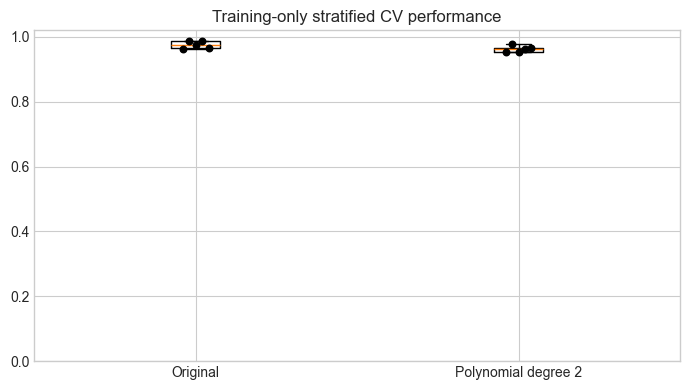

In [17]:
plot_data = pd.DataFrame(
    {
        "Original": original_cv_scores[PRIMARY_METRIC],
        "Polynomial degree 2": polynomial_cv_scores[PRIMARY_METRIC],
    }
).melt(var_name="Feature space", value_name="F1 macro")

fig, ax = plt.subplots(figsize=(7, 4))
labels = list(plot_data["Feature space"].unique())
groups = [
    plot_data.loc[plot_data["Feature space"] == label, "F1 macro"].to_numpy()
    for label in labels
]
ax.boxplot(groups, tick_labels=labels)
for position, values in enumerate(groups, start=1):
    offsets = np.linspace(-0.04, 0.04, len(values))
    ax.scatter(position + offsets, values, color="black", s=22, zorder=3)
ax.set_title("Training-only stratified CV performance")
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()


# 17. Final Test Evaluation

This is the first post-split section that transforms or evaluates `X_test`/`y_test`. Classical configurations were fixed in advance and are evaluated once. Quantum test evaluation must remain disabled until mapping and $T$ have been selected exclusively from training CV.


In [ ]:
# This is the first post-split cell that transforms or evaluates the reserved test set.
original_test_result = evaluate_classifier(
    X_train,
    X_test,
    y_train,
    y_test,
)

final_polynomial_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_train_polynomial_final = final_polynomial_transformer.fit_transform(X_train)
X_test_polynomial_final = final_polynomial_transformer.transform(X_test)
polynomial_test_result = evaluate_classifier(
    X_train_polynomial_final,
    X_test_polynomial_final,
    y_train,
    y_test,
)

final_test_results = pd.DataFrame(
    [
        {
            "feature_space": "Original",
            "input_dimension": X_train.shape[1],
            **{key: original_test_result[key] for key in METRIC_COLUMNS},
        },
        {
            "feature_space": "Polynomial degree 2",
            "input_dimension": X_train_polynomial_final.shape[1],
            **{key: polynomial_test_result[key] for key in METRIC_COLUMNS},
        },
    ]
)
display(final_test_results)

if RUN_QW_EXPERIMENTS:
    print(
        "Quantum final evaluation must use only the mapping and T selected by "
        "training CV, then fit on all training data and transform the test set once."
    )
else:
    print("Quantum final test evaluation skipped: no external implementation supplied.")


# 18. Final Summary

- The Breast Cancer Wisconsin data use one reproducible, stratified 80/20 Train/Test split.
- Mutual-information selection, scaling, mapping selection, and $T$ optimization are restricted to training data; performance-based configuration selection uses stratified cross-validation.
- The classifier is fixed logistic regression so the experiment isolates changes in feature space.
- Original and polynomial feature spaces run end-to-end. The 1D and 2D Quantum Walk paths are explicit interfaces only and remain skipped until external implementations are supplied.
- The Test set is used only in the final evaluation section.
